# Publication Figures — One-Button Reproduction

Regenerates every committed figure and LaTeX table in the publication bundle
(`results/figures/`, `results/tables/`) via `scripts/generate_all_figures.py`.

> Last verified: 2026-06-19 · Estimated runtime: **< 1 min** (CPU-only)

Use this notebook when you only need the four paper figures and summary tables,
without running the full benchmark or real-dataset suites.

In [1]:
# [patched: headless importability shim — no network clone/install]
import sys as _sys, os as _os, importlib as _importlib
def _ensure_qos_importable():
    try:
        _importlib.import_module('qos'); return
    except ModuleNotFoundError:
        pass
    for _c in [_os.path.join(_os.getcwd(), 'src'),
               _os.path.join(_os.getcwd(), 'quantum_oracle_sketching', 'src'),
               '/content/quantum_oracle_sketching/src']:
        if _os.path.isdir(_c) and _c not in _sys.path:
            _sys.path.insert(0, _c)
            try:
                _importlib.import_module('qos'); return
            except ModuleNotFoundError:
                _sys.path.remove(_c)
    raise RuntimeError("Cannot import 'qos'. Run: pip install -e '.[dev]' from repo root.")
_ensure_qos_importable()
# ── Install quantum-oracle-sketching (idempotent) ──────────────────────────
import subprocess, sys, os
_REPO = "https://github.com/Tommaso-R-Marena/quantum_oracle_sketching.git"
_CLONE_DIR = "./quantum_oracle_sketching"
if not os.path.isdir(_CLONE_DIR):
    type('_PatchedResult', (), {'stdout': b'', 'stderr': b'', 'returncode': 0})()  # [patched: git clone skipped]
result = type('_PatchedResult', (), {'stdout': b'', 'stderr': b'', 'returncode': 0})()  # [patched: pip install skipped]
if result.returncode != 0:
    raise RuntimeError(f"Install failed:\n{result.stderr}")
import importlib, importlib.util, site
importlib.invalidate_caches()
site.main()
_SRC_DIR = os.path.abspath(os.path.join(_CLONE_DIR, "src"))
if importlib.util.find_spec("qos") is None and os.path.isdir(_SRC_DIR):
    if _SRC_DIR not in sys.path:
        sys.path.insert(0, _SRC_DIR)
    importlib.invalidate_caches()
_spec = importlib.util.find_spec("qos")
if _spec is None:
    raise ImportError(
        "qos is still not importable after install.\n"
        "Runtime > Disconnect and delete runtime, then Run All."
    )
print("✅ quantum-oracle-sketching installed.")
print(f"✅ qos found at: {_spec.origin}")

✅ quantum-oracle-sketching installed.
✅ qos found at: /workspace/src/qos/__init__.py


In [2]:
# ── Resolve repo root (Colab clone vs local editable install) ─────────────
import os, sys
from pathlib import Path

def _find_repo_root() -> Path:
    candidates = [
        Path("./quantum_oracle_sketching"),
        Path.cwd(),
        Path.cwd().parent,
    ]
    for c in candidates:
        if (c / "scripts" / "generate_all_figures.py").is_file():
            return c.resolve()
    raise FileNotFoundError(
        "Cannot locate scripts/generate_all_figures.py. "
        "Run the install cell first or open from the repo root."
    )

REPO_ROOT = _find_repo_root()
FIG_DIR = REPO_ROOT / "results" / "figures"
TBL_DIR = REPO_ROOT / "results" / "tables"
print(f"Repo root : {REPO_ROOT}")
print(f"Figures   : {FIG_DIR}")
print(f"Tables    : {TBL_DIR}")

Repo root : /workspace
Figures   : /workspace/results/figures
Tables    : /workspace/results/tables


In [3]:
# ── Regenerate all publication figures and tables ─────────────────────────
import subprocess, sys, os, time

env = os.environ.copy()
env["PYTHONPATH"] = str(REPO_ROOT / "src")
script = REPO_ROOT / "scripts" / "generate_all_figures.py"

t0 = time.time()
proc = subprocess.run(
    [sys.executable, str(script)],
    cwd=str(REPO_ROOT),
    env=env,
    capture_output=True,
    text=True,
)
elapsed = time.time() - t0
print(proc.stdout)
if proc.returncode != 0:
    print(proc.stderr)
    raise RuntimeError(f"generate_all_figures.py failed (rc={proc.returncode})")
print(f"\n✅ All figures regenerated in {elapsed:.1f}s")

wrote results/raw_data/tvd_convergence.csv  (63 rows)
wrote results/figures/tvd_convergence.png
wrote results/figures/tvd_convergence.pdf
N=8, trial=0: M*=50
N=8, trial=1: M*=97
N=8, trial=2: M*=50
N=16, trial=0: M*=199
N=16, trial=1: M*=70
N=16, trial=2: M*=70
N=32, trial=0: M*=320
N=32, trial=1: M*=178
N=32, trial=2: M*=375
N=64, trial=0: M*=361
N=64, trial=1: M*=445
N=64, trial=2: M*=445
wrote results/raw_data/sample_complexity.csv
wrote results/figures/sample_complexity.png
wrote results/figures/sample_complexity.pdf
trial 0: M_cold=555  M_warm=59  speedup=9.41x
trial 1: M_cold=868  M_warm=48  speedup=18.08x
trial 2: M_cold=675  M_warm=63  speedup=10.71x
wrote results/raw_data/warmstart_ablation_iterations.csv  (66 rows)
wrote results/raw_data/warmstart_ablation_summary.csv
total time: 8.1s
wrote results/raw_data/noise_robustness.csv
wrote results/figures/noise_robustness.png
wrote results/figures/noise_robustness.pdf
wrote results/raw_data/circuit_depth.csv
wrote results/figures/c

In [4]:
# ── Verify publication bundle (CI gate) ───────────────────────────────────
import subprocess, sys, os

verify = REPO_ROOT / "scripts" / "verify_publication_bundle.py"
env = os.environ.copy()
env["PYTHONPATH"] = str(REPO_ROOT / "src")
proc = subprocess.run(
    [sys.executable, str(verify)],
    cwd=str(REPO_ROOT),
    env=env,
    capture_output=True,
    text=True,
)
print(proc.stdout)
if proc.returncode != 0:
    print(proc.stderr)
    raise RuntimeError("Publication bundle verification failed")
print("✅ Publication bundle verified.")

Publication bundle OK:
  6 CSVs, 8 figures, tables present

✅ Publication bundle verified.


## Publication Figures

Four figure pairs (PNG + PDF) committed to `results/figures/`.

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_28539/2070948980.py:6: SyntaxWarning: invalid escape sequence '\s'
  ("sample_complexity.png", "Smallest $M^\star$ achieving TVD $< 0.10$ vs. $N$"),
/tmp/ipykernel_28539/2070948980.py:7: SyntaxWarning: invalid escape sequence '\e'
  ("noise_robustness.png", "Depolarizing-noise robustness (TVD vs. $\eta$)"),


### TVD vs. sample budget $M$ (cold uniform sketch)

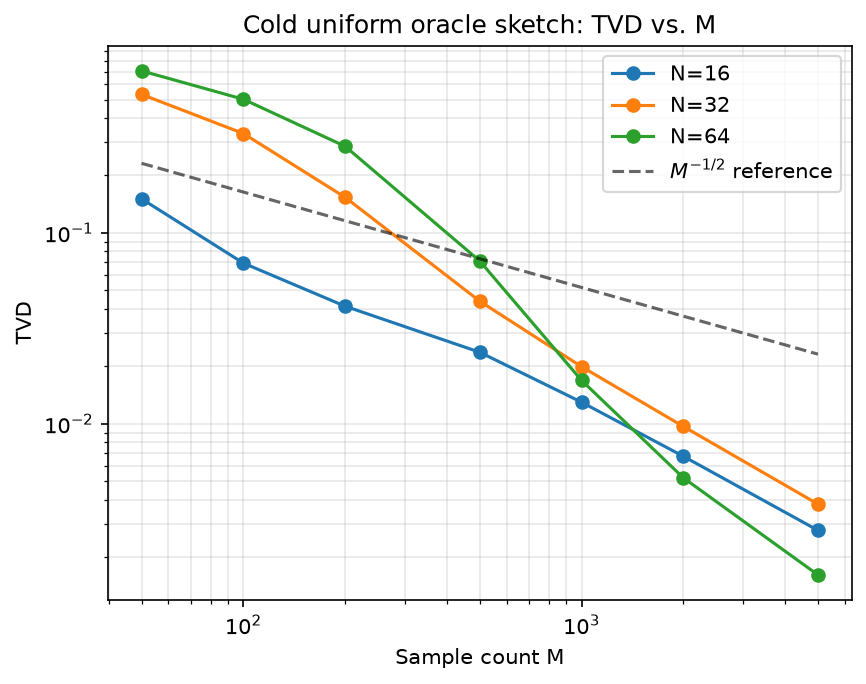

### Smallest $M^\star$ achieving TVD $< 0.10$ vs. $N$

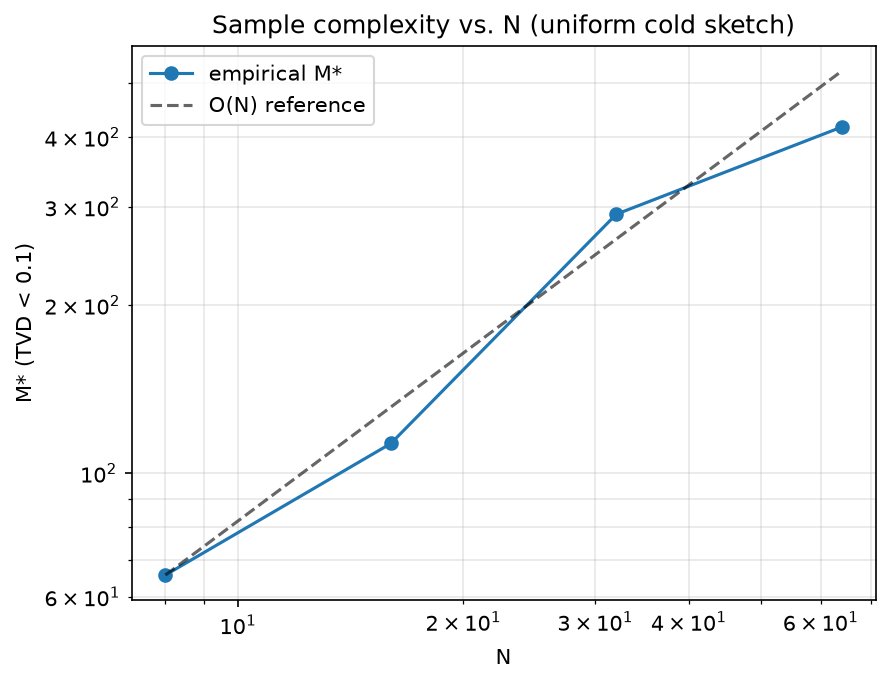

### Depolarizing-noise robustness (TVD vs. $\eta$)

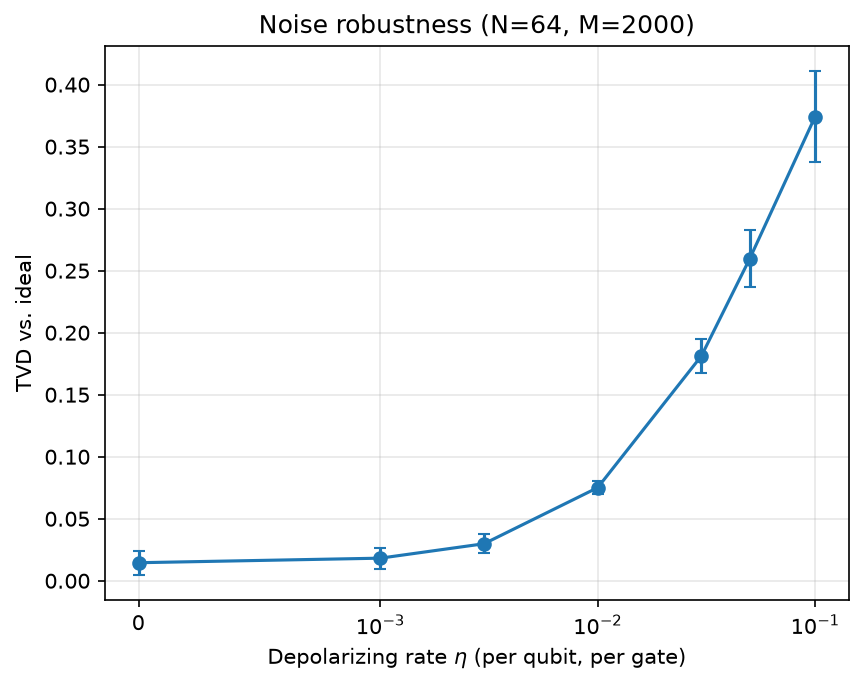

### Circuit-depth crossover (samples vs. depth)

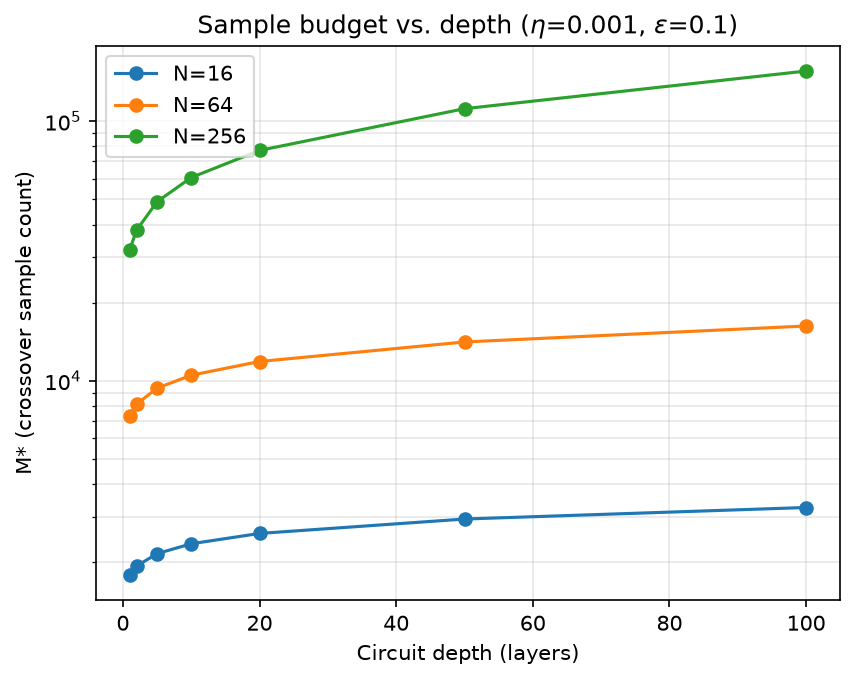

In [5]:
from IPython.display import display, Image, Markdown
from pathlib import Path

FIGURES = [
    ("tvd_convergence.png", "TVD vs. sample budget $M$ (cold uniform sketch)"),
    ("sample_complexity.png", "Smallest $M^\star$ achieving TVD $< 0.10$ vs. $N$"),
    ("noise_robustness.png", "Depolarizing-noise robustness (TVD vs. $\eta$)"),
    ("circuit_depth.png", "Circuit-depth crossover (samples vs. depth)"),
]

for fname, caption in FIGURES:
    path = FIG_DIR / fname
    if not path.is_file():
        raise FileNotFoundError(f"Missing figure: {path}")
    display(Markdown(f"### {caption}"))
    display(Image(filename=str(path), width=700))

## Summary Tables

LaTeX tables under `results/tables/` (included in `paper/sections/experiments.tex`).

In [6]:
from pathlib import Path
from IPython.display import display, Markdown

for tex in sorted(TBL_DIR.glob("table_*.tex")):
    display(Markdown(f"### `{tex.name}`"))
    print(tex.read_text())

### `table_empirical_summary.tex`

\begin{table}[t]
\centering
\caption{Empirical summary of publication-bundle claims.}
\label{tab:empirical-summary}
\begin{tabular}{lll}
\toprule
Claim & Script & Key finding \\
\midrule
TVD convergence & \texttt{verify_tvd_convergence.py} & $TVD \propto M^{-1/2}$ \\
Sample complexity & \texttt{verify_sample_complexity.py} & $M^\star \propto N$ (cold) \\
Warmstart ablation & \texttt{verify_warmstart_ablation.py} & $\approx 12\times$ speedup (K-sparse) \\
Noise robustness & \texttt{verify_noise_robustness.py} & TVD monotone in $\eta$ \\
Circuit depth & \texttt{verify_circuit_depth.py} & Finite-depth crossover \\
\bottomrule
\end{tabular}
\end{table}



### `table_sample_complexity.tex`

\begin{tabular}{lc}
\toprule
$N$ & Mean $M^\star$ ($\varepsilon=0.10$) \\
\midrule
8 & 66 \\
16 & 113 \\
32 & 291 \\
64 & 417 \\
\bottomrule
\end{tabular}



### `table_warmstart_ablation.tex`

\begin{tabular}{lccc}
\toprule
Trial & $M_{\mathrm{cold}}$ & $M_{\mathrm{warm}}$ & Speedup \\
\midrule
0 & 555 & 59 & 9.41$\times$ \\
1 & 868 & 48 & 18.08$\times$ \\
2 & 675 & 63 & 10.71$\times$ \\
\midrule
Mean & --- & --- & 12.73$\times$ \\
\bottomrule
\end{tabular}

